In [1]:
import sys
import pycbc
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import astropy
import h5py

import pycbc
import gwosc
import gwpy
import bilby
import corner
import emcee

print("All core GW workshop modules imported successfully")

print(sys.version)
print(pycbc.__version__)
print(sys.executable)

/home/krist/.local/share/uv/python/cpython-3.13.15-linux-x86_64-gnu/lib/python3.13/importlib/__init__.py:88: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


All core GW workshop modules imported successfully
3.13.15 (main, Aug 25 2026, 14:01:07) [Clang 22.1.3 ]
2.11.0
/home/krist/pycbc-env/bin/python


### Day 27 - Gravitational Workshop

We know from the fundamental interactions, that gravity is the weakest of them all. If we use the strong force as our relative example, then gravitation is $10^{-38}$ times weaker.

However on large scales gravity adds up.

Our current understanding of gravity is based on Einsteins general relativity, where
- Spacetime is a 4 dimensional continuum

> $$x^\mu = (ct,x,y,z)$$

- The spacetime geometry is related to the matter content
- Spacetime is very rigid

The following equation describes this: (There would also be a cosmological constant term that has been ignored)

$$G_{\mu v} = \kappa T_{\mu \nu}$$

Where 
- $G_{\mu \nu}$ relates to the geometry/curvature of space time
- $\kappa$ is a small constant
- $T_{\mu \nu}$ is the mass and energy (or the distribution of energy, momentum, pressure etc)

Each of these are tensors

### How do we get gravitational waves?

Say spacetime is nearly flat, then we can split the spacetime metric as:



$$
g_{\mu\nu}
=
\eta_{\mu\nu}
+
h_{\mu\nu}.
$$

Where,
- $g_{\mu \nu}$ is the actual spacetime metric
- $\eta_{\mu \nu}$ is flat Minkowski spacetime

> The spacetime of special relativity with no gravitational curvature, looking like:
$$
\eta_{\mu\nu}
=
\begin{pmatrix}
-1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{pmatrix}
$$


- $h_{\mu \nu}$ is a small perturbation

And we assume that $|h_{\mu\nu}|\ll 1$. This means that space time is mostly flat with small disturbances that travel through it.

Due to how small it is, high order terms of $h_{\mu \nu}$ are discarded to simplify the einstein field equations. Hence this linearises the equations and forms our weak field approximation

> The weak field approximation only assumes gravity is causing a small deviation from flat spacetime as we have modelled above.

Hence, in a vacuum, the perturbation satsifies the wave type equation:

$$
\Box h_{\mu\nu}
=
0.
$$

>Where the $\Box$ is the d'Alembertian operator (spacetime analagous to the Laplacian), and just means that the small spacetime perturbation satisifes a wave equation in our case, where
> $$\Box=-\frac{1}{c^2}\frac{\partial^2}{\partial t^2}+\nabla^2$$
> So pretty much $\Box$ measures how a field curves in space and time together, meaning that when it equals 0, there is no local source in that region. And the perturbation can propagate freely through the vacuum as a gravitational wave
>


But the consequence of this is that systems with their mass distribution changing assymetrically with time can radiate gravitational waves, which are waves in the spacetime curvature. They're transverse and propagate at the speed of light 

This means that the gravitational waves only squeeze and stretch space in directions perpendicular to their propagation.

**To detect these gravitational waves, they need to be very strong**, one such system is a binary system with a black hole and neutron star orbitting one another. They continuously radiate gravitational wave energy, meaning their orbital energy decreases, and such, their separation decreases.

As they get closer, their orbital frequency also rises producing something known as **chirp**, where:
- amplitude increases
- frequency increases
- ends in a merger

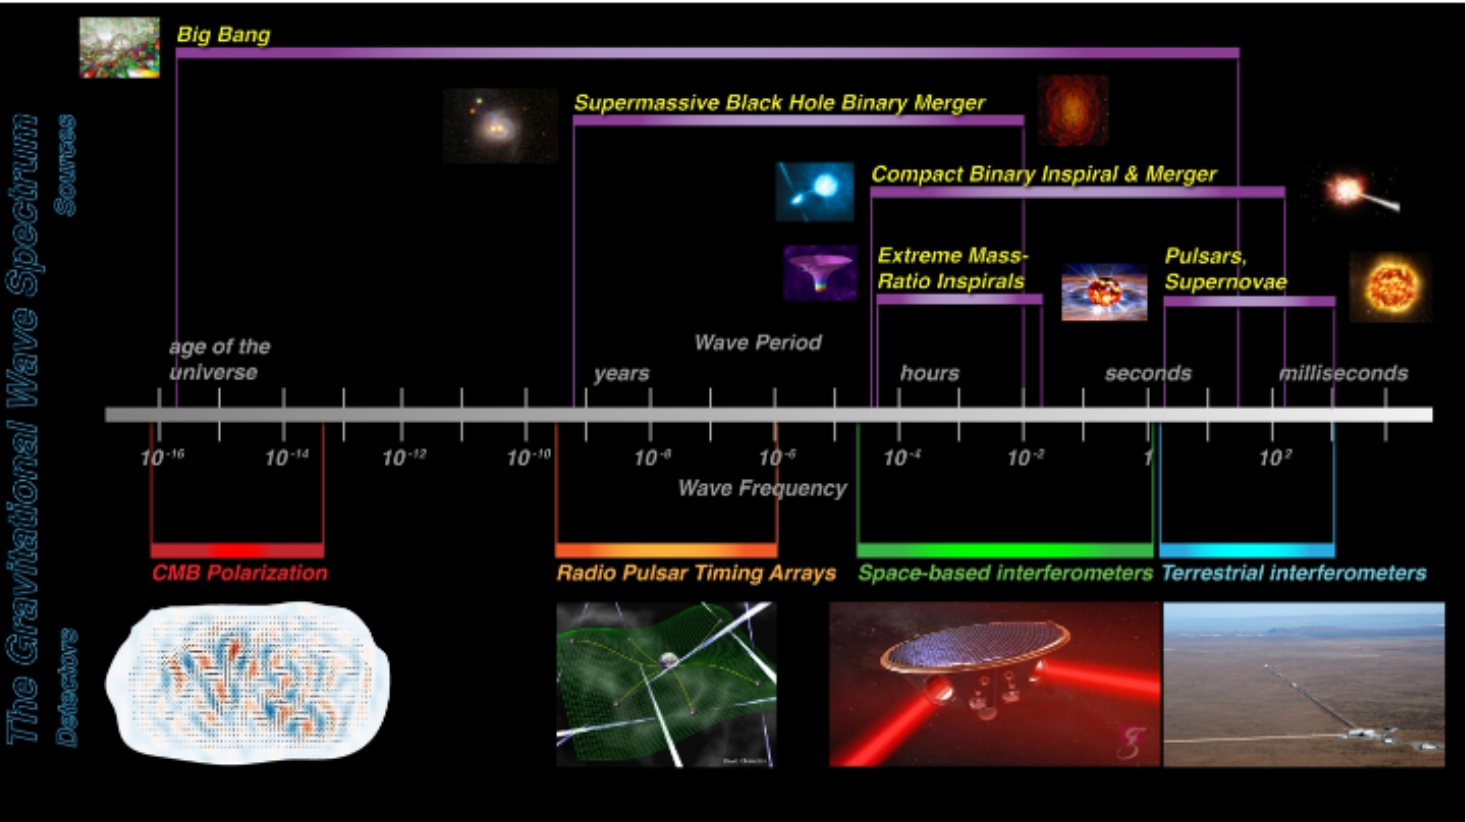

This is the full gravitational spectrum and shows what instrumentation is required to detect gravitational waves at certain wavelengths, and we will be focusing on the Terrestrial interferometers.

### Terrestrial interferometers

For this workshop we are mainly focusing on terrestrial interferometers such as **LIGO, Virgo and KAGRA**.

The basic idea behind these detectors is a Michelson interferometer:

- A laser is split into two perpendicular arms
- The beams travel down each arm, reflect from mirrors and return
- They are recombined and interfere with one another
- A gravitational wave stretches one arm while squeezing the other, changing the relative distance travelled by the light

This changes the phase of the returning light and therefore the interference pattern at the detector.

> So we detect the incredibly small change it causes in the relative lengths of the two arms.


### Strain

The quantity that gravitational wave detectors measure is known as **strain**:

$$
h(t)=\frac{\Delta L(t)}{L}
$$

Where

- $L$ is the original arm length
- $\Delta L$ is the change in the relative arm length
- $h(t)$ is dimensionless

For LIGO,

$$
L=4\text{ km}
$$

but the gravitational waves we detect typically have strains of approximately

$$
h\sim10^{-21}
$$

Therefore,

$$
\Delta L=hL
$$

giving roughly

$$
\Delta L\sim4\times10^{-18}\text{ m}
$$

> This means that LIGO is measuring changes in distance much smaller than the size of a proton.


### What does the detector actually give us?

After the detector output has been calibrated, what we get is a **strain time series**.

We can approximately think of this as:

$$
d(t)=h(t)+n(t)
$$

Where

- $d(t)$ is the measured data
- $h(t)$ is the gravitational wave signal
- $n(t)$ is detector noise

The issue is that the gravitational wave signal can be much smaller than the detector noise.

> So our main computational problem is "How can we find a known or expected signal hidden inside noisy data?"


### Detector noise

The detector noise is not the same at every frequency.

This means that LIGO noise is **coloured noise**, rather than white noise.

To describe how the noise changes with frequency we use the*Power Spectral Density (PSD) as follows:

$$
S_n(f)
$$

A related quantity is the **Amplitude Spectral Density (ASD)**:

$$
\text{ASD}(f)=\sqrt{S_n(f)}
$$

> A lower PSD/ASD means that the detector is more sensitive at that frequency.

Different noise sources dominate different frequency ranges:

- Low frequencies are seismic/environmental noise
- Intermediate frequencies are thermal noise
- High frequencies are quantum/shot noise

This explains why a terrestrial interferometer only has a certain frequency range where it is particularly sensitive.


### Compact Binary Coalescences

The main sources we will focus on are **Compact Binary Coalescences (CBCs)**.

These involve combinations such as:

- Black hole + black hole
- Neutron star + neutron star
- Black hole + neutron star

As the binary loses energy through gravitational waves,

$$
E_{\text{orbit}}\downarrow
$$

its separation decreases,

$$
r\downarrow
$$

and its orbital frequency increases,

$$
f_{\text{orbit}}\uparrow
$$

For an approximately circular binary, the dominant gravitational wave frequency is approximately

$$
f_{\text{GW}}\approx2f_{\text{orbit}}
$$

Hence, as the two objects move closer together, the gravitational wave frequency increases

This gives us the **chirp** that I meantioned before.

The signal can be divided into three stages:
- **Inspiral** where the objects orbit one another and gradually move closer
- **Merger** where the two objects coalesce or collide 
- **Ringdown** where the final black hole settles into its stable state


### Matched filtering

Because we know what a compact binary gravitational wave signal should look like,we can compare the detector data against predicted waveform templates. This is known as **matched filtering**

> This is basically how similar is the measured detector data to the waveform that we expect from a binary merger?

However, frequencies where the detector has lots of noise should contribute less to this comparison.

This is where power spectral density comes in

> PSD tells us how the power of a signal id distrubuted across frequency

The noise weighted inner product is:

$$
(a|b)
=
4\,\text{Re}
\int_0^\infty
\frac{\tilde{a}(f)\tilde{b}^*(f)}
{S_n(f)}
\,df
$$


where, $\frac{1}{S_n(f)}$ means

- High detector noise means that frequency contributes less
- Low detector noise means that frequency contributes more

We can then define the matched filter signal to noise ratio approximately as:

$$
\rho
=
\frac{(d|h)}
{\sqrt{(h|h)}}
$$

Where

- $d$ is the detector data
- $h$ is our waveform template
- $\rho$ is the signal-to-noise ratio

> So matched filtering is essentially searching noisy detector data for a waveform whose shape we already approximately know.

# overall pipeline


$$

\text{Gravitational wave}
\rightarrow
\text{strain } h(t)
\rightarrow
\text{detector data}
\rightarrow
\text{PSD/noise}
\rightarrow
\text{matched filtering}

$$


### Accessing GWOSC data

The Gravitational Wave Open Science Center (GWOSC) provides public LVK data.

The main useful data is

- **Strain data** which is the main gravitational wave measurement
- **Data-quality information** which tells us when the detector data is suitable for analysis
- **Segments/timelines** which are the periods when the detectors were operating in science mode
- **Event results** which include parameter estimation results, skymaps and other products for detected events

GW data are commonly labelled using **GPS time**, measured in seconds from January 6th 1980

The data can be downloaded in formats such as **HDF5**, which we can read nicely in python, we can also use packages like **GWpy** and **PyCBC** to access GWOSC data directly.

> An important point is that we cannot analyse every recorded second of detector data. Detectors may not be operating correctly or may fail data-quality requirements, so GW analyses uses selected valid data segments

Detected transient gravitational-wave events are collected into Gravitational-Wave Transient Catalogues (GWTCs).

Not much more really here.

Let's now look at how to use the open data:

In [2]:
import gwosc
print(gwosc.__version__)

0.8.3


How do we find what datasets exist?

In [3]:
from gwosc.datasets import find_datasets

print(find_datasets(type="catalog"))

['GWTC', 'GWTC-1-confident', 'GWTC-1-marginal', 'GWTC-2', 'GWTC-2.1-auxiliary', 'GWTC-2.1-confident', 'GWTC-2.1-marginal', 'GWTC-3-confident', 'GWTC-3-marginal', 'GWTC-4.0', 'GWTC-4.1', 'GWTC-5.0', 'IAS-O3a', 'Initial_LIGO_Virgo', 'O1_O2-Preliminary', 'O3_Discovery_Papers', 'O3_IMBH_marginal', 'O4_Discovery_Papers']


In [4]:
from gwosc import datasets

gwtc1 = datasets.find_datasets(
    type="events",
    catalog="GWTC-1-confident"
)

print(gwtc1)

['GW150914-v3', 'GW151012-v3', 'GW151226-v2', 'GW170104-v2', 'GW170608-v3', 'GW170729-v1', 'GW170809-v1', 'GW170814-v3', 'GW170817-v3', 'GW170818-v1', 'GW170823-v1']


The naming convention here used should be dissected:

GW150914-v3 means:
1. GW - gravitational wave event
2. 15 -2015
3. 09 - September
4. 14 - 14th day

In [5]:
datasets.find_datasets(
    type="events",
    catalog="GWTC-1-confident",
    detector="L1",
    segment=(1164556817, 1187733618)
)

['GW170104-v2',
 'GW170608-v3',
 'GW170729-v1',
 'GW170809-v1',
 'GW170814-v3',
 'GW170817-v3',
 'GW170818-v1',
 'GW170823-v1']

The segment  = (start, stop) gives a time interval in GPS seconds, so this code is asking what confident GWTC-1 events occured in the livingston data during this time interval

In [6]:
from gwosc.datasets import run_segment

print(run_segment("O1")) # Allows us to find the time range of the observing catalogue

(1126051217, 1137254417)


In [7]:
O1_events = datasets.find_datasets(
    type="events",
    catalog="GWTC-1-confident",
    segment=run_segment("O1")
)

print(O1_events)

['GW150914-v3', 'GW151012-v3', 'GW151226-v2']


Once we know which event we want, we can use GWOSC to return the URLs for the associated data files:

In [8]:
from gwosc.locate import get_event_urls

urls = get_event_urls("GW150914")
print(urls)

['https://gwosc.org/archive/data/O1/1126170624/H-H1_LOSC_4_V1-1126256640-4096.hdf5', 'https://gwosc.org/archive/data/O1/1126170624/L-L1_LOSC_4_V1-1126256640-4096.hdf5']


So here we get files associated with both Hanford and Livingston where:

- H1 = LIGO Hanford
- L1 = LIGO Livingston
- V1 = Virgo
- K1 = KAGRA
- G1 = GEO600

We can also request a specific detector

In [9]:
urls = get_event_urls(
    "GW150914",
    duration=16,
    detector="L1"
)

print(urls)

['https://gwosc.org/archive/data/O1/1126170624/L-L1_LOSC_4_V1-1126256640-4096.hdf5']


### Querying events by their properties

We can also search the GWOSC catalogue based on event properties rather than by event name.

For example, we can find events with a network matched-filter SNR between 25 and 30:

```python
from gwosc.datasets import query_events

events = query_events(
    select=[
        "25 <= network-matched-filter-snr <= 30"
    ]
)

print(events)

```

I had no idea I could do this, this should make the notebooks a lot more fun!

There are some questions that it wanted answering too:

**What can be accessed from the Gravitational Wave Open Science Center?**

- We can access strain data, data quality information, valid observing timelines and event analysis results.

**How many months did O2 last?**

In [10]:
from gwosc.datasets import run_segment

start, end = run_segment("O2")

seconds = end - start
days = seconds / (60 * 60 * 24)
months = days / 30

print(days, months)

268.25001157407405 8.941667052469136


Hence about 9 months

In [11]:
# How many confident GWTC -3 events occurent during O3b?

from gwosc import datasets
from gwosc.datasets import run_segment

events = datasets.find_datasets(
    type = "events",
    catalog= "GWTC-3-confident",
    segment= run_segment("O3b")

)

print(len(events))


35


How many unique events have a network matched filter SNR of at least 30?

In [12]:
from gwosc.datasets import query_events

events = query_events(
    select=["network-matched-filter-snr >= 30"]
)

print(events)


['GW250207_115645-v1', 'GW250114_082203-v2', 'GW241127_061008-v1', 'GW241011_233834-v2', 'GW240925_005809-v1', 'GW240925_005809-v2', 'GW240920_124024-v1', 'GW231226_101520-v1', 'GW231226_101520-v2', 'GW230814_230901-v1', 'GW230814_230901-v2', 'GW230814_230901-v3', 'GW170817-v3']


I can't lie I got something different here... but it seems like the answer is 3

### How do we actually load the data?

### GWpy and PyCBC

These are the two important Python packages for analysing gw data:

- **GWpy** is convenient for accessing, manipulating and visualising the detector data
- **PyCBC** is designed for gravitational wave analysis, including waveform and matched filtering tools

Both represent strain data using `TimeSeries` objects

In [13]:
import gwpy
import pycbc # cant install this unfortunately

Let's load some!

In [14]:
from gwosc.datasets import event_gps

gps = event_gps("GW190412")
print(gps)

1239082262.1


In [15]:
start, stop = segment = (
    int(gps) - 5,
    int(gps) + 5
)

print(segment)

(1239082257, 1239082267)


In [16]:
from gwpy.timeseries import TimeSeries

ldata = TimeSeries.fetch_open_data(
    "L1",
    *segment,
    verbose=True
)

This isn't a numpy array its a timeseires object that contains 
- strain values
- units
- sampling information
- metadata

For this data,

$$\Delta t = \frac{1}{40196}s$$

hence the sampling frequency is:

$$f_s = 4096 Hz$$

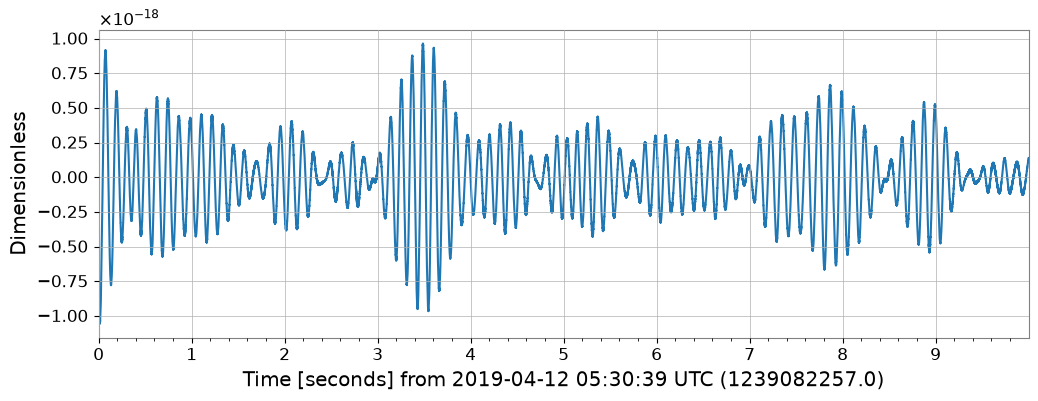

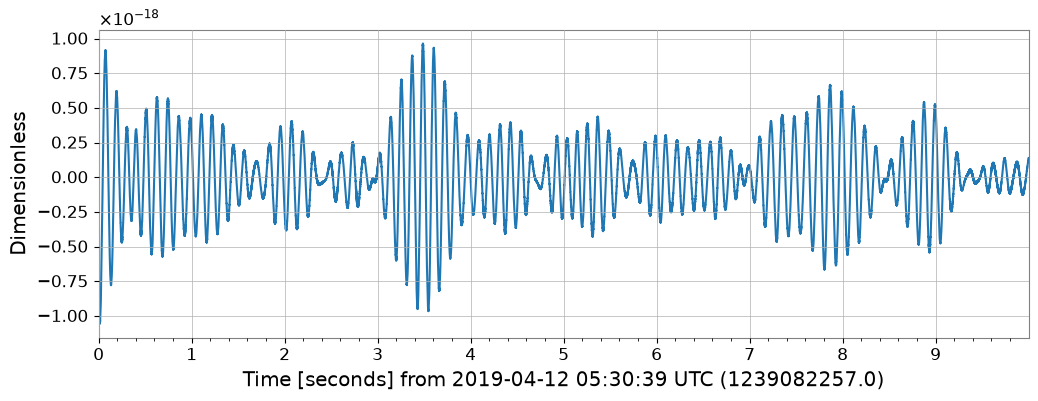

In [17]:
ldata.plot()

This is the actual Livingston strain around GW190412

Okay now time for the question:

In [18]:
from gwosc.datasets import event_gps

gps = event_gps("GW190412")
print(gps)

1239082262.1


In [19]:
from gwpy.timeseries import TimeSeries

segment = (
    int(gps) - 5,
    int(gps) + 5
)

ldata = TimeSeries.fetch_open_data(
    "H1",
    *segment
)

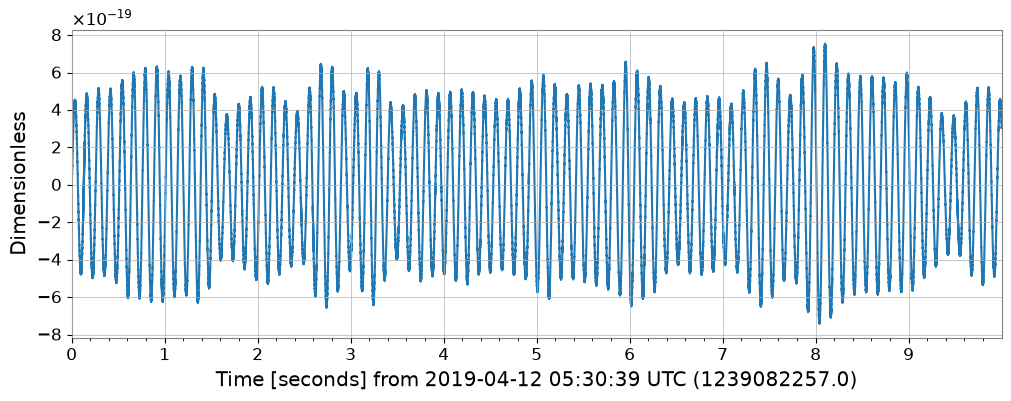

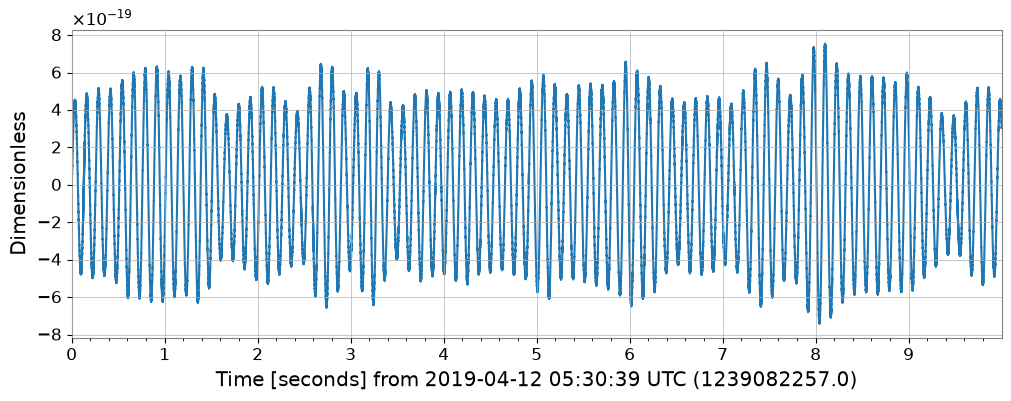

In [20]:
ldata.plot()

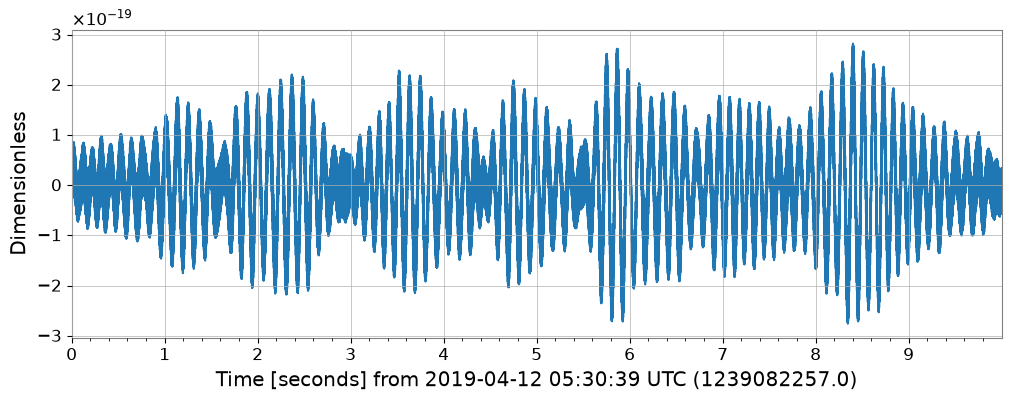

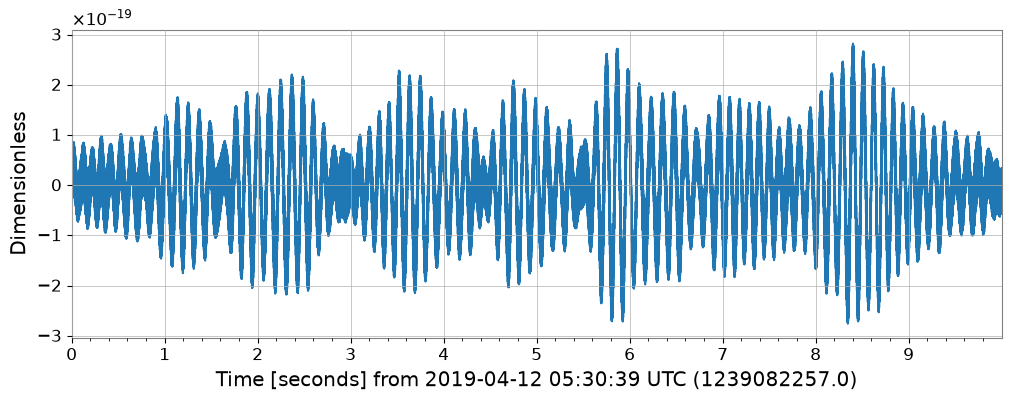

In [21]:
vdata = TimeSeries.fetch_open_data(
    "V1",
    *segment
)

vdata.plot()

You cant really identify the signal by eye from the raw strain, the noise dominates so much.

Text(0.5, 1.0, 'Data from Virgo')

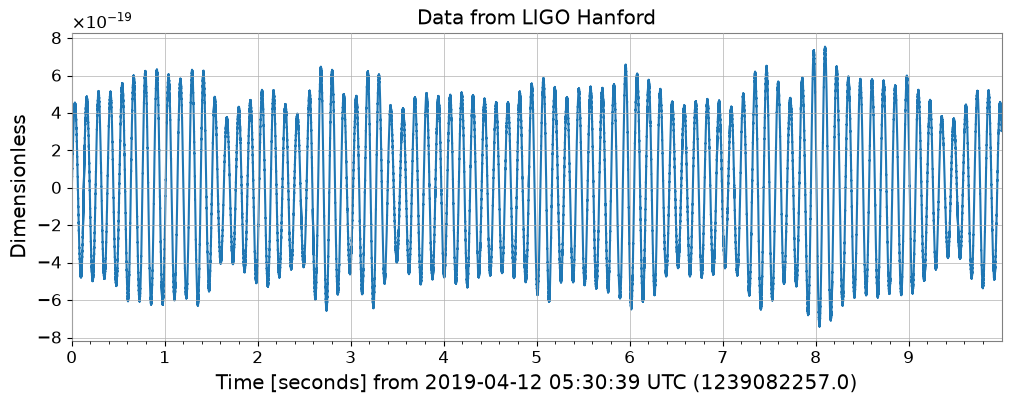

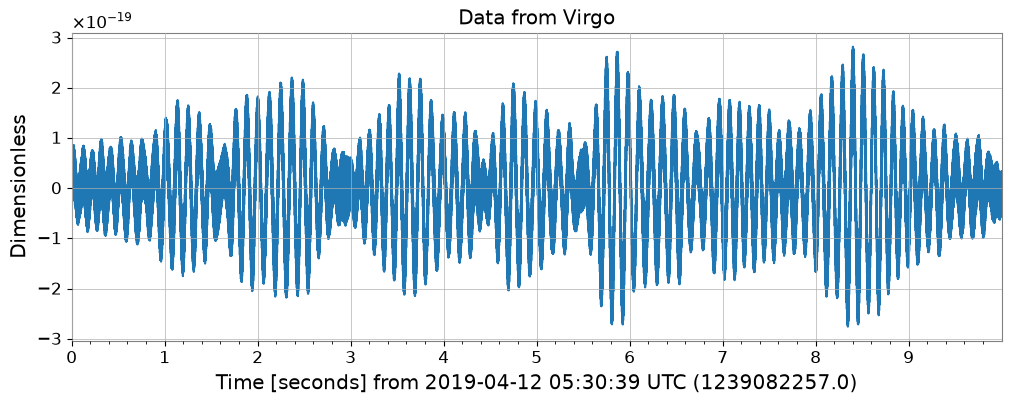

In [22]:
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps
import matplotlib.pyplot as plt

gps = event_gps('GW190412')
segment = (int(gps)-5, int(gps)+5)

hdata = TimeSeries.fetch_open_data('H1', *segment, verbose=True)
hdata.plot()
plt.title('Data from LIGO Hanford')

vdata = TimeSeries.fetch_open_data('V1', *segment, verbose=True)
vdata.plot()
plt.title('Data from Virgo')


In [23]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import scipy
import matplotlib.pyplot as plt

from ipywidgets import interact, interactive, fixed, interact_manual, widgets

### Generating Waveforms

In [ ]:
from pycbc.waveform import get_fd_waveform

hp, hc = get_fd_waveform( # This gives a frequency series, td would give a timeseries
    approximant="IMRPhenomXAS",
    mass1=10,
    mass2=10,
    f_lower=30,
    inclination=np.pi/3,
    delta_f=1/8 # Adjacent frequency samples are separated by 0.125Hz
)

Here we are just asking how much of the waveform exists at each frequency instead of what the strain is

The time domain tells us what the detector strain does as time passes, whereas the frequency domain tells us how the signal is distributed across frequencies. We will be able to move between these using fourier transforms

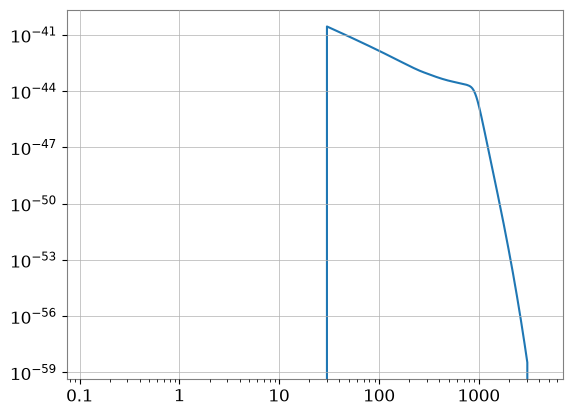

In [ ]:
plt.loglog(hp.sample_frequencies, hp.squared_norm()) # sample frequency is the frequency corresponding to each element, and the other is the squared magnitude of the waveform

In [27]:
from pycbc.waveform import fd_approximants
fd_approximants()

['EccentricFD',
 'TaylorF2',
 'TaylorF2Ecc',
 'TaylorF2NLTides',
 'TaylorF2RedSpin',
 'TaylorF2RedSpinTidal',
 'SpinTaylorF2',
 'EOBNRv2_ROM',
 'EOBNRv2HM_ROM',
 'SEOBNRv1_ROM_EffectiveSpin',
 'SEOBNRv1_ROM_DoubleSpin',
 'SEOBNRv2_ROM_EffectiveSpin',
 'SEOBNRv2_ROM_DoubleSpin',
 'SEOBNRv2_ROM_DoubleSpin_HI',
 'Lackey_Tidal_2013_SEOBNRv2_ROM',
 'SEOBNRv4_ROM',
 'SEOBNRv4HM_ROM',
 'SEOBNRv4_ROM_NRTidal',
 'SEOBNRv4_ROM_NRTidalv2',
 'SEOBNRv4_ROM_NRTidalv2_NSBH',
 'SEOBNRv4T_surrogate',
 'IMRPhenomA',
 'IMRPhenomB',
 'IMRPhenomC',
 'IMRPhenomD',
 'IMRPhenomD_NRTidal',
 'IMRPhenomD_NRTidalv2',
 'IMRPhenomNSBH',
 'IMRPhenomHM',
 'IMRPhenomP',
 'IMRPhenomPv2',
 'IMRPhenomPv2_NRTidal',
 'IMRPhenomPv2_NRTidalv2',
 'SpinTaylorT4Fourier',
 'SpinTaylorT5Fourier',
 'NRSur4d2s',
 'IMRPhenomXAS',
 'IMRPhenomXHM',
 'IMRPhenomPv3',
 'IMRPhenomPv3HM',
 'IMRPhenomXP',
 'IMRPhenomXPHM',
 'SEOBNRv5_ROM',
 'IMRPhenomXAS_NRTidalv2',
 'IMRPhenomXP_NRTidalv2',
 'IMRPhenomXO4a',
 'ExternalPython',
 'SEOBNRv5HM